# Week 2 — Tasks

This notebook implements the Week 2 exercises using only concepts and tools already introduced in this repository. It follows the existing Week 2 notebook first, then uses the repo's Week 1 data, indicators, backtester, and reporting flow for the real-market step.


## Setup

Use the same project-root pattern and the same lightweight MLP style shown in the existing Week 2 notebook.


In [21]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.getcwd(), '.tmp', 'matplotlib'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.features import FEATURE_NAMES, build_pooled_dataset
from tradinglab.metrics import directional_accuracy, information_coefficient
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.report import report
from tradinglab.strategies.predictor import model_to_strategy


class MLP(nn.Module):
    def __init__(self, n_features, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_with_history(model, X_train, y_train, X_test, y_test, epochs=200, lr=1e-2):
    Xtr = torch.tensor(X_train)
    ytr = torch.tensor(y_train)
    Xte = torch.tensor(X_test)
    yte = torch.tensor(y_test)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train': [], 'test': []}
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = nn.functional.mse_loss(model(Xtr), ytr)
        loss.backward()
        opt.step()

        history['train'].append(loss.item())
        model.eval()
        with torch.no_grad():
            history['test'].append(nn.functional.mse_loss(model(Xte), yte).item())
    return history


def predict_array(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X)).numpy()


## Data

Load the local EGX universe and define one chronological split that we reuse for the real-stock task.


In [22]:
feed = DataFeed.from_dir('data/egx')
lookback = 30
split_day = int(feed.n_days * 0.7)
top_k = 2

assert split_day >= lookback

print('universe:', feed.symbols)
print('days:', feed.n_days)
print('date range:', str(feed.dates[0])[:10], '->', str(feed.dates[-1])[:10])
print('train through:', str(feed.dates[split_day - 1])[:10])
print('test from:', str(feed.dates[split_day])[:10])
print('feature columns:', FEATURE_NAMES)


universe: ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']
days: 1159
date range: 2021-10-20 -> 2026-07-30
train through: 2025-02-19
test from: 2025-02-20
feature columns: ['return', 'p/sma_fast', 'p/sma_slow', 'rsi', 'volatility']


## Task 1 — Something an MLP fits easily

Start with the same clean function from the existing Week 2 notebook. Because this is not a time series, the split is shuffled rather than chronological.


In [23]:
torch.manual_seed(0); np.random.seed(0)

x = np.linspace(-3, 3, 800).reshape(-1, 1).astype('float32')
noise = np.random.randn(*x.shape) * 0.3
y = (x**2 - 2*x + noise).astype('float32').ravel()

# random shuffle split -- this is a static function, not a time series
idx = np.random.permutation(len(x))
split = int(len(x) * 0.7)
train_idx, test_idx = idx[:split], idx[split:]
Xtr, ytr = x[train_idx], y[train_idx]
Xte, yte = x[test_idx], y[test_idx]

model1 = MLP(1)
history1 = train_with_history(model1, Xtr, ytr, Xte, yte, epochs=400, lr=0.01)

noise_floor = float((noise**2).mean())
print(f'final train loss: {history1["train"][-1]:.4f}')
print(f'final test loss:  {history1["test"][-1]:.4f}')
print(f'theoretical noise floor: {noise_floor:.4f}  (the best any model could ever do)')
print(f'test loss is {history1["test"][-1] / noise_floor:.2f}x the noise floor')


final train loss: 0.1070
final test loss:  0.1078
theoretical noise floor: 0.0898  (the best any model could ever do)
test loss is 1.20x the noise floor


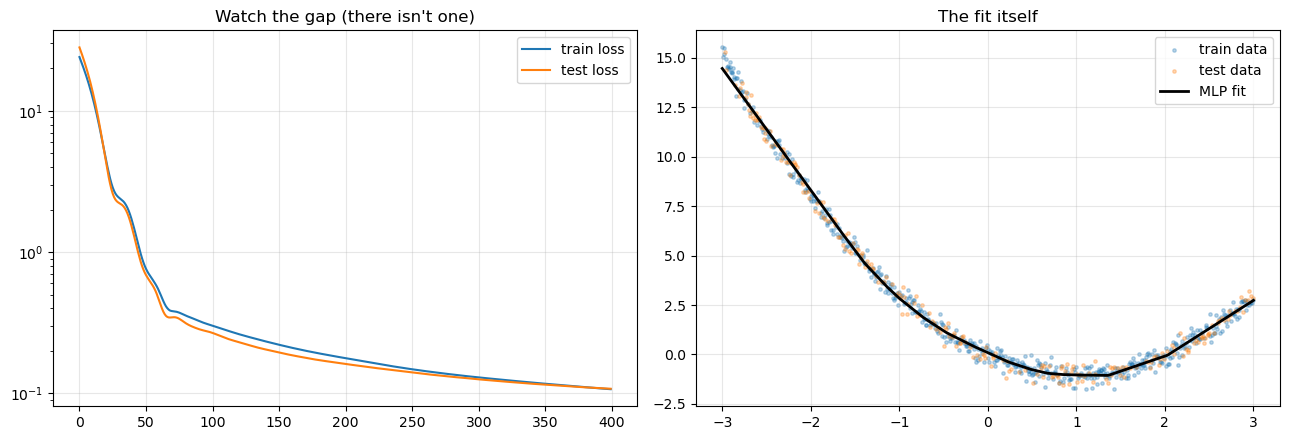

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history1['train'], label='train loss')
axes[0].plot(history1['test'], label='test loss')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title("Watch the gap (there isn't one)")

x_sorted = np.linspace(-3, 3, 300).reshape(-1, 1).astype('float32')
with torch.no_grad():
    y_pred = model1(torch.tensor(x_sorted)).numpy()
axes[1].scatter(x[train_idx], y[train_idx], s=6, alpha=.3, label='train data')
axes[1].scatter(x[test_idx], y[test_idx], s=6, alpha=.3, label='test data')
axes[1].plot(x_sorted, y_pred, color='black', linewidth=2, label='MLP fit')
axes[1].legend(); axes[1].grid(alpha=.3); axes[1].set_title('The fit itself')
plt.tight_layout(); plt.show()


## Task 2 — Now a wave — same size problem, same size network

Keep the model the same, but switch to a true time-series next-step prediction where the test period is the future.


In [25]:
torch.manual_seed(0); np.random.seed(0)

t = np.linspace(0, 200*np.pi, 4000)
series = np.sin(t) + 0.03*np.random.randn(len(t))

X = series[:-1].reshape(-1, 1).astype('float32')
y = series[1:].astype('float32')

# chronological split this time -- this IS a time series, test must be the future
split = int(len(X) * 0.7)
Xtr, ytr = X[:split], y[:split]
Xte, yte = X[split:], y[split:]

model2 = MLP(1)
history2 = train_with_history(model2, Xtr, ytr, Xte, yte, epochs=300, lr=0.01)

# the baseline that costs nothing to compute: "predict tomorrow = today"
persistence_loss = float(np.mean((Xte.squeeze(-1) - yte)**2))

print(f'final train loss: {history2["train"][-1]:.5f}')
print(f'final test loss:  {history2["test"][-1]:.5f}')
print(f'"just predict no change" loss: {persistence_loss:.5f}')


final train loss: 0.01395
final test loss:  0.01402
"just predict no change" loss: 0.01410


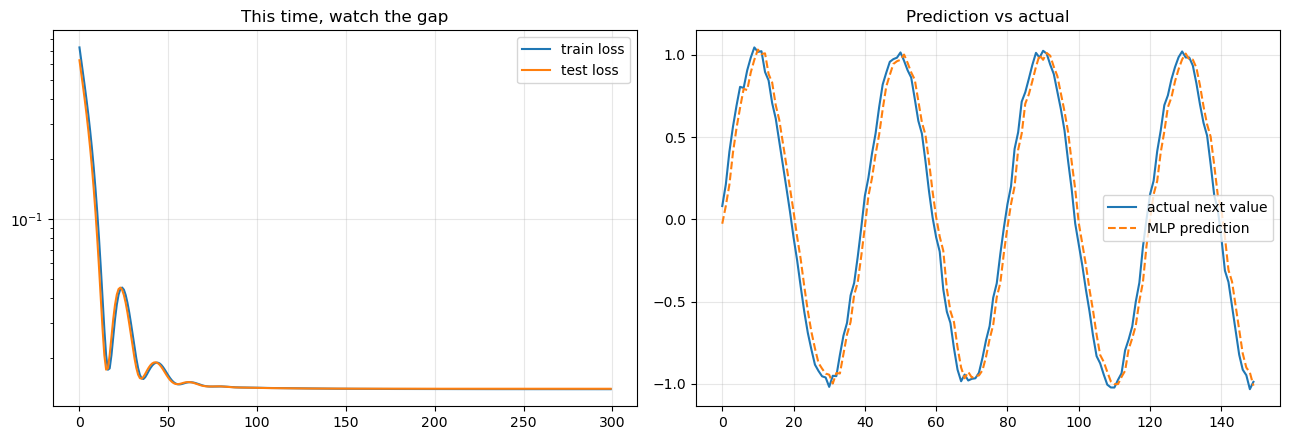

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history2['train'], label='train loss')
axes[0].plot(history2['test'], label='test loss')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title('This time, watch the gap')

pred_test = predict_array(model2, Xte)
show_n = 150
axes[1].plot(y[split:split+show_n], label='actual next value', linewidth=1.5)
axes[1].plot(pred_test[:show_n], label='MLP prediction', linewidth=1.5, linestyle='--')
axes[1].legend(); axes[1].grid(alpha=.3); axes[1].set_title('Prediction vs actual')
plt.tight_layout(); plt.show()


## Task 3 — We try it on a real stock's returns and see what actually happens

Use the repository's Week 1 indicators as features, split the history by calendar day, train on the early period only, then backtest the learned ranking on the later unseen period.


In [27]:
# calendar-day split across all stocks -- no stock contributes late-period rows to training
X_train, y_train, X_test, y_test = build_pooled_dataset(feed, split_day)

assert X_train.shape[1] == len(FEATURE_NAMES)
assert not np.isnan(X_train).any() and not np.isnan(y_train).any()
assert not np.isnan(X_test).any() and not np.isnan(y_test).any()

print('train rows:', X_train.shape[0], '| test rows:', X_test.shape[0])
print('n_features:', X_train.shape[1], '| feature names:', FEATURE_NAMES)


train rows: 26588 | test rows: 11798
n_features: 5 | feature names: ['return', 'p/sma_fast', 'p/sma_slow', 'rsi', 'volatility']


In [28]:
torch.manual_seed(0); np.random.seed(0)

model3 = MLP(X_train.shape[1])
history3 = train_with_history(model3, X_train, y_train, X_test, y_test, epochs=200, lr=0.01)
pred_test = predict_array(model3, X_test)

zero_baseline_loss = float(np.mean(y_test**2))
print(f'final train loss: {history3["train"][-1]:.6f}')
print(f'final test loss:  {history3["test"][-1]:.6f}')
print(f'"predict zero return" loss: {zero_baseline_loss:.6f}')
print(f'directional accuracy: {directional_accuracy(pred_test, y_test):.3f}')
print(f'information coefficient: {information_coefficient(pred_test, y_test):.4f}')


final train loss: 0.000952
final test loss:  0.000578
"predict zero return" loss: 0.000579
directional accuracy: 0.439
information coefficient: 0.0098


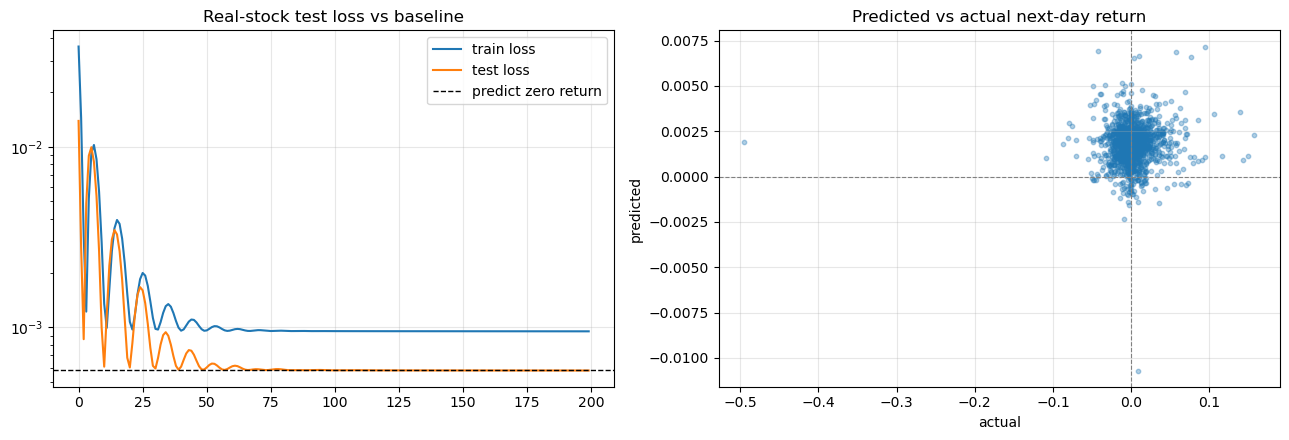

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history3['train'], label='train loss')
axes[0].plot(history3['test'], label='test loss')
axes[0].axhline(zero_baseline_loss, color='black', linestyle='--', linewidth=1.0,
                label='predict zero return')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title('Real-stock test loss vs baseline')

show_n = min(1500, len(y_test))
axes[1].scatter(y_test[:show_n], pred_test[:show_n], s=10, alpha=.35)
axes[1].axhline(0.0, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(0.0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Predicted vs actual next-day return')
axes[1].set_xlabel('actual')
axes[1].set_ylabel('predicted')
axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()


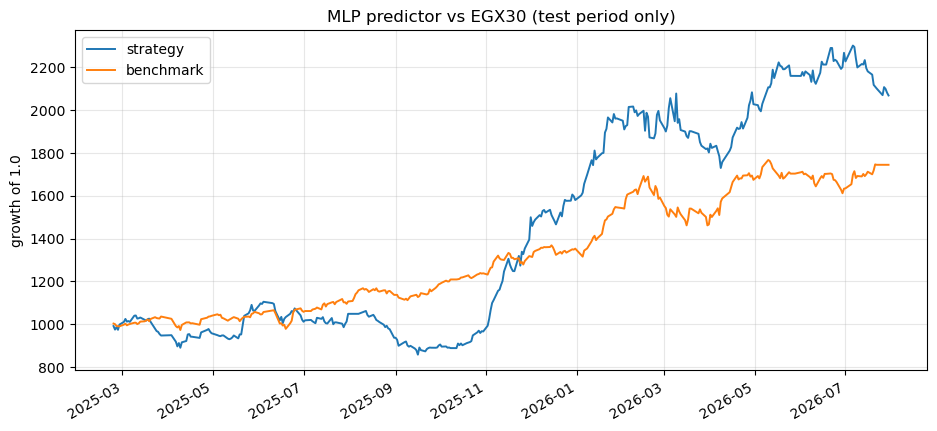

total return   : +106.8%
sharpe         : 1.88
max drawdown   : 22.3%
final value    : 2068.38   (benchmark 1744.54)
beat benchmark : YES
                 you beat the benchmark by 324 EGP


In [30]:
strategy = model_to_strategy(model3, top_k=top_k)
sim = PortfolioSimulator(feed, benchmark='egx30')

# start=split_day means the first earned return is fully out-of-sample
result = run_backtest(sim, strategy, lookback=lookback, start=split_day)

assert len(result['portfolio']) == feed.n_days - 1 - split_day
assert str(result['dates'][0])[:10] == str(feed.dates[split_day + 1])[:10]

report(result, title='MLP predictor vs EGX30 (test period only)', start_capital=1000.0)
